In [1]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-06/option_chain_nifty_2026-04-07_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([22000, 22200, 22250, 22300, 22350, 22400, 22450, 22500, 22550,
       22600, 22650, 22700, 22750, 22800, 22850, 22900, 22950, 23000,
       23050, 23100, 23150, 23200, 23300, 23500])

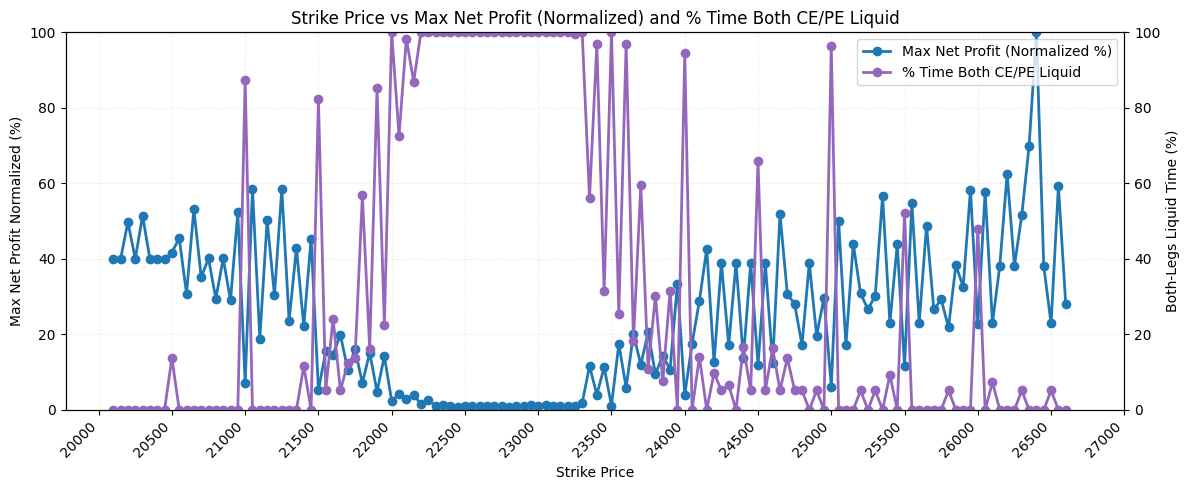

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,20100,249.894717,39.975802,0.0
1,20150,249.883592,39.974022,0.0
2,20200,311.019560,49.753979,0.0
3,20250,249.961267,39.986448,0.0
4,20300,321.455238,51.423380,0.0


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

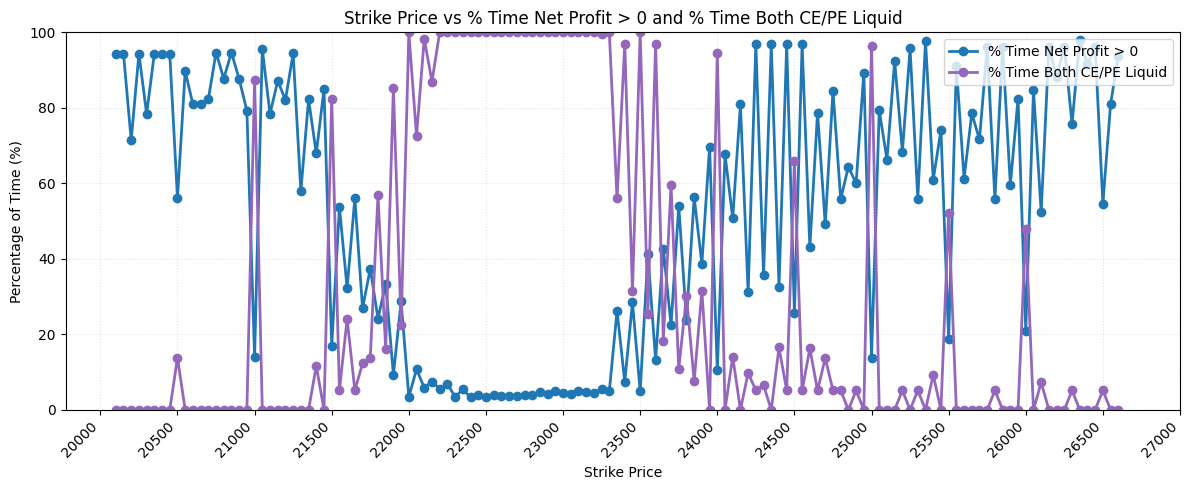

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,20100,94.222539,0.0
1,20150,94.365193,0.0
2,20200,71.398003,0.0
3,20250,94.365193,0.0
4,20300,78.388017,0.0


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

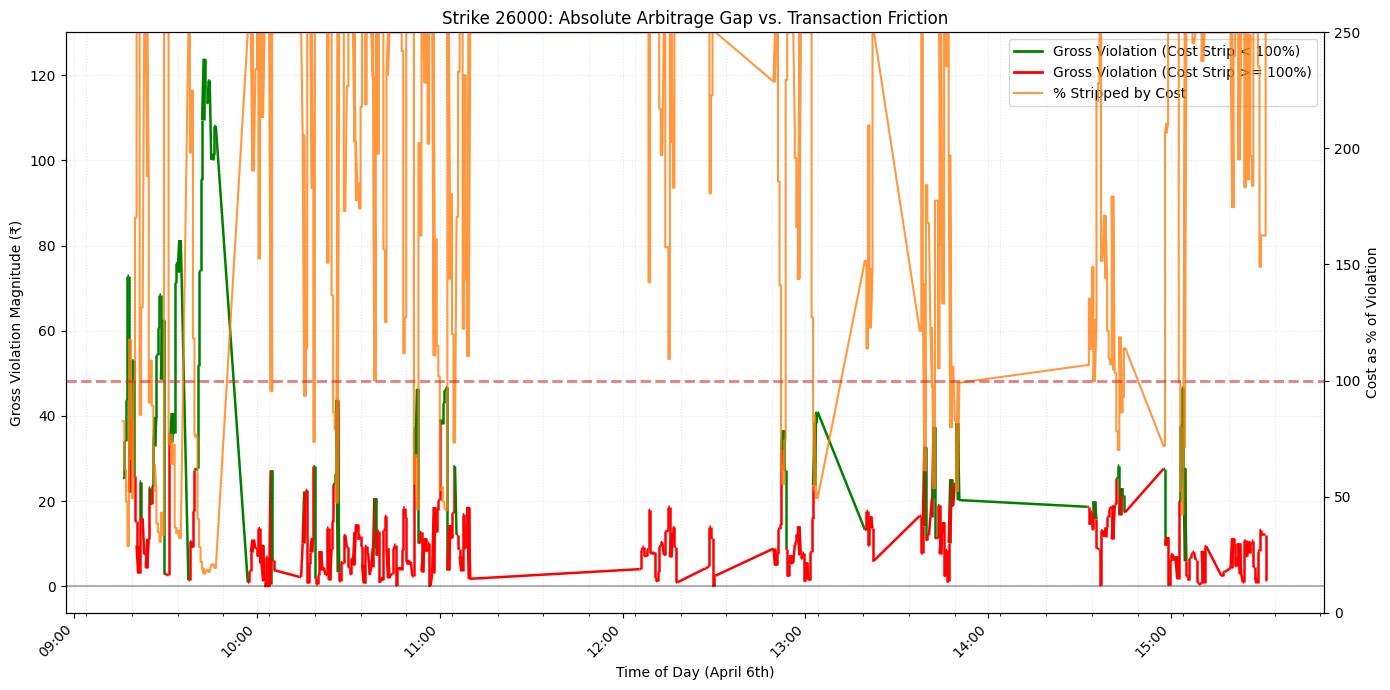

,fetch_time,abs_violation,cost,cost_stripped_pct
118,2026-04-06 09:16:00,25.426388,20.968114,82.465954
2083,2026-04-06 09:16:30,25.427872,20.966473,82.454691
2214,2026-04-06 09:16:30,34.027872,20.960633,61.598423
4048,2026-04-06 09:17:00,34.029356,20.958992,61.590917
4310,2026-04-06 09:17:00,43.779356,20.952537,47.859401
...,...,...,...,...
1453039,2026-04-06 15:30:30,12.137829,19.716110,162.435221
1454873,2026-04-06 15:31:00,12.139313,19.714466,162.401822
1455004,2026-04-06 15:31:00,1.389313,19.721484,1419.513063
1456838,2026-04-06 15:31:30,1.390797,19.719840,1417.880281


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [7]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

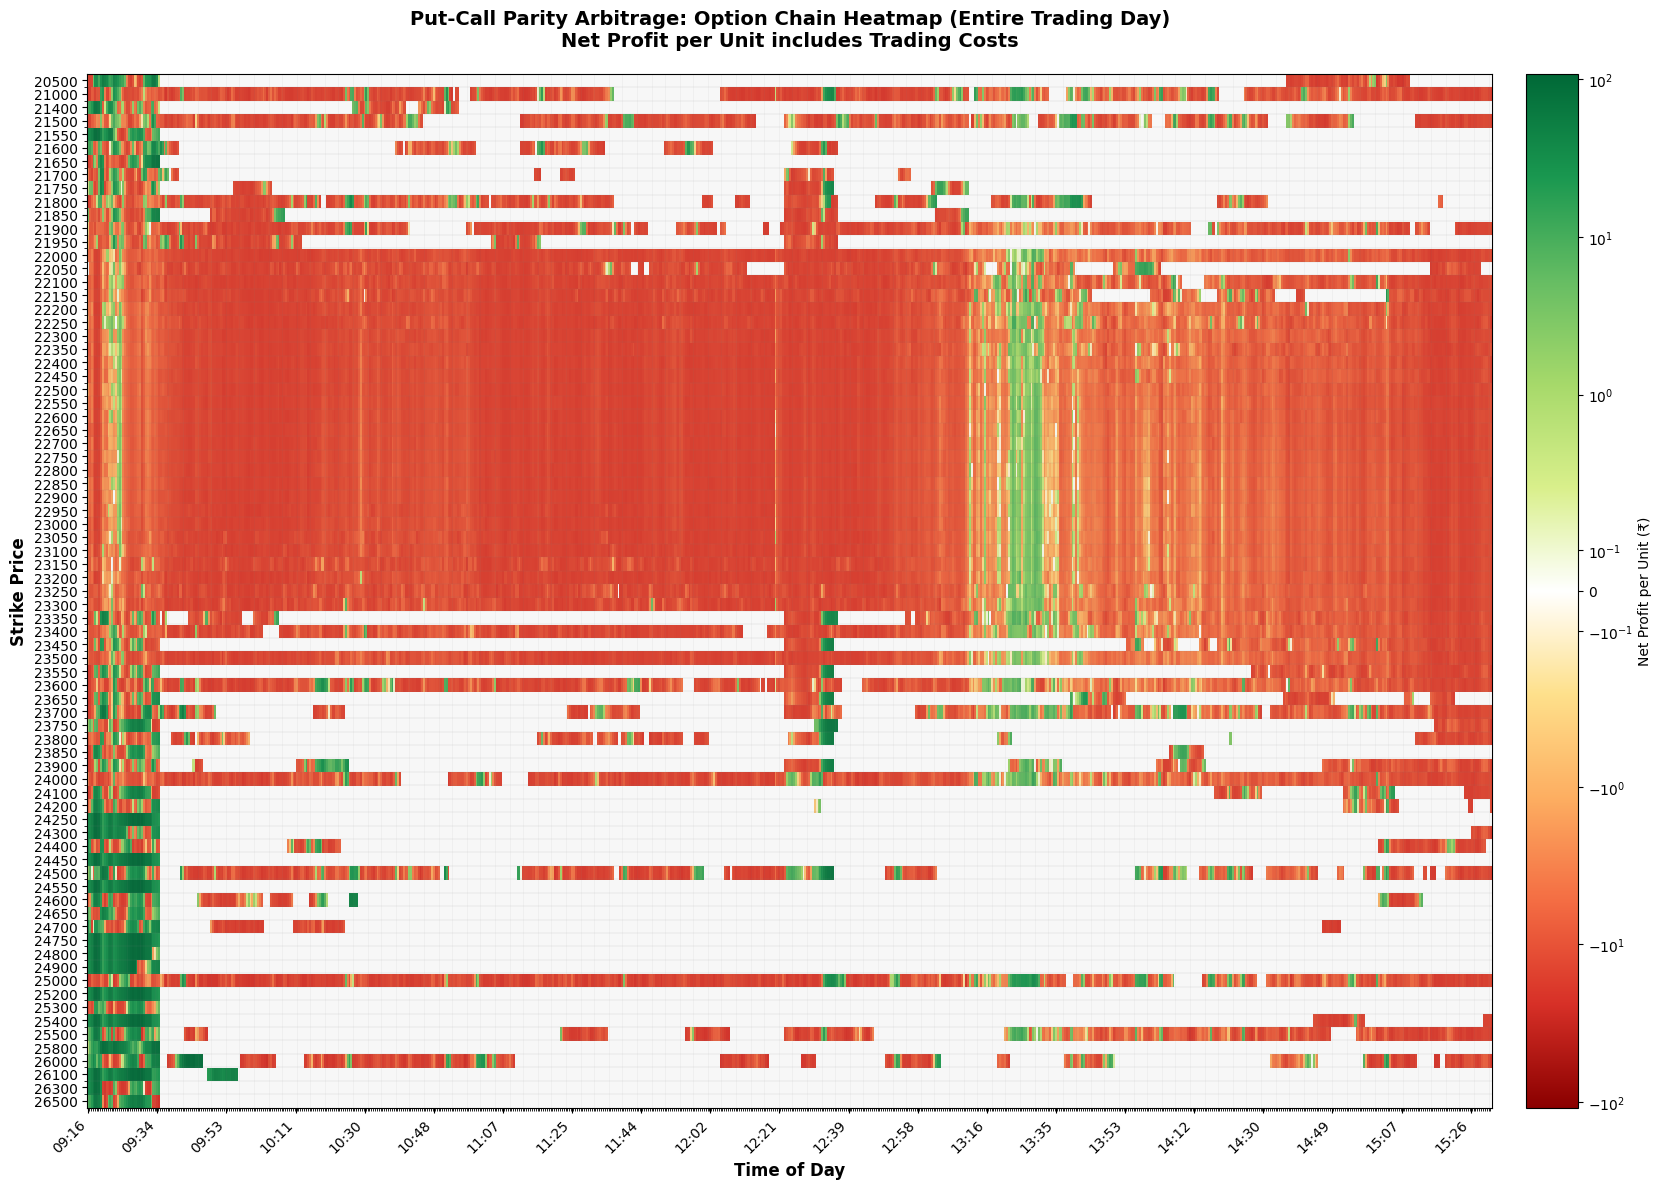

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [9]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

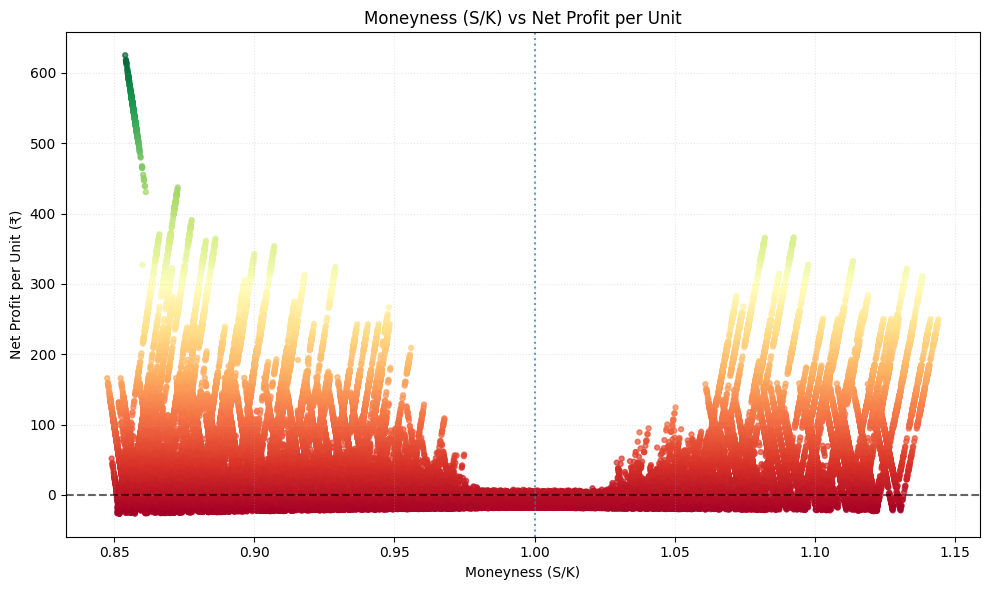

,moneyness,net_profit_per_unit
0,1.128241,23.172300
1,1.125442,23.176063
2,1.122656,15.559941
3,1.119884,23.233781
4,1.117126,23.387660


In [10]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df,
    min_liquidity=0,
)
moneyness_df.head()

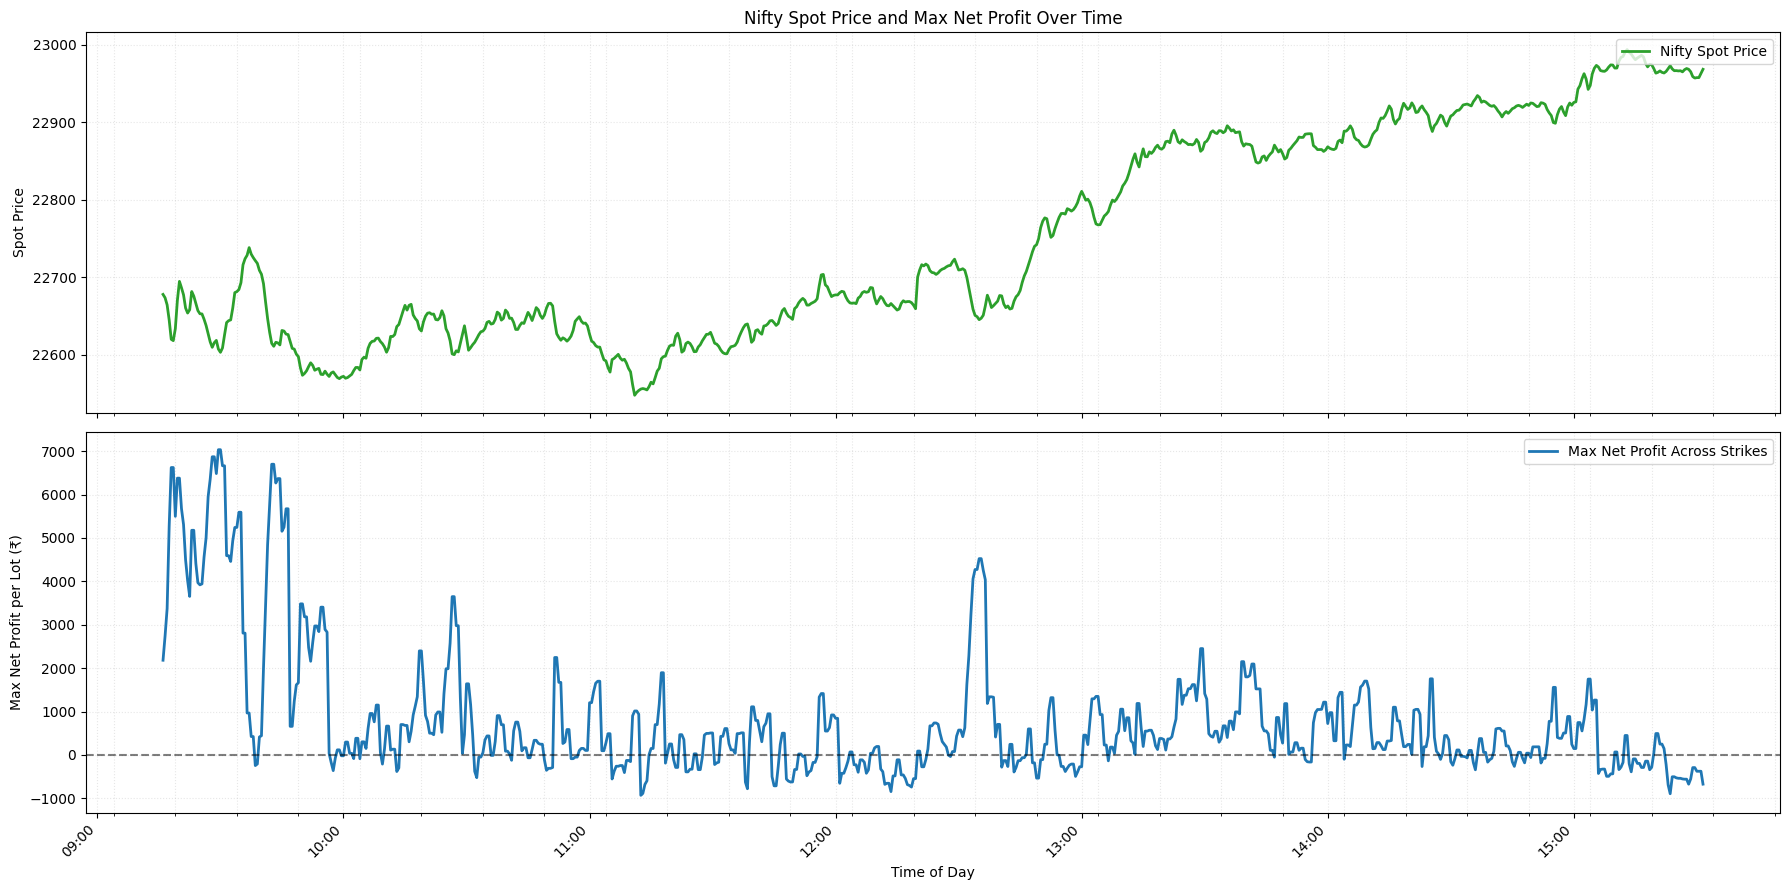

,fetch_time,spot_price,max_profit
0,2026-04-06 09:16:00,22677.650,2181.874183
1,2026-04-06 09:16:30,22673.325,2741.444453
2,2026-04-06 09:17:00,22664.125,3372.562047
3,2026-04-06 09:17:30,22644.675,5271.999690
4,2026-04-06 09:18:00,22619.725,6621.833204


In [11]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

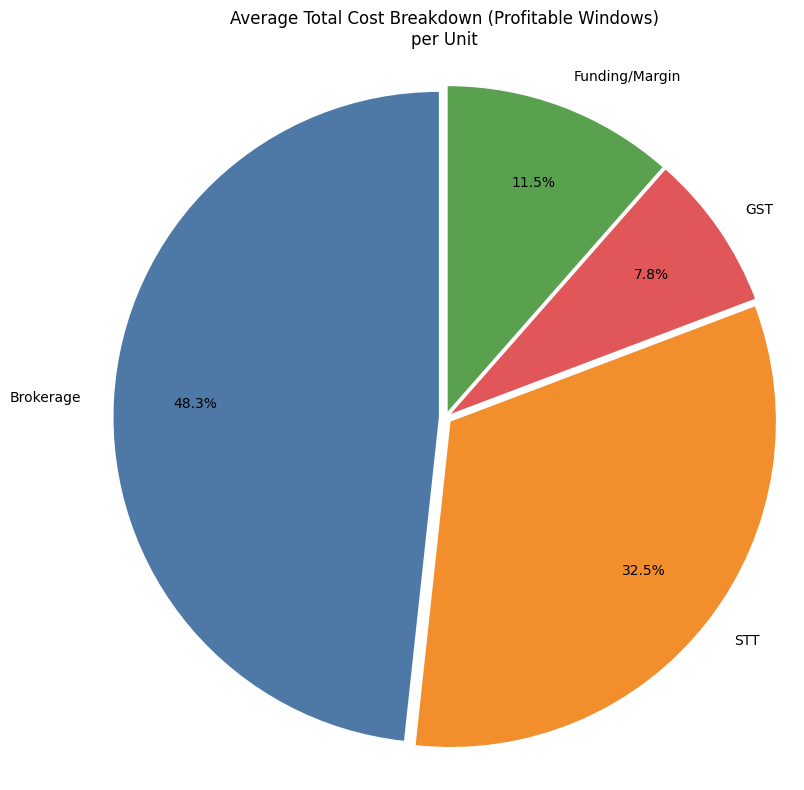

,avg_cost_per_unit
Brokerage,9.381232
STT,6.307893
GST,1.508622
Funding/Margin,2.229486
Total,19.427232


In [12]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

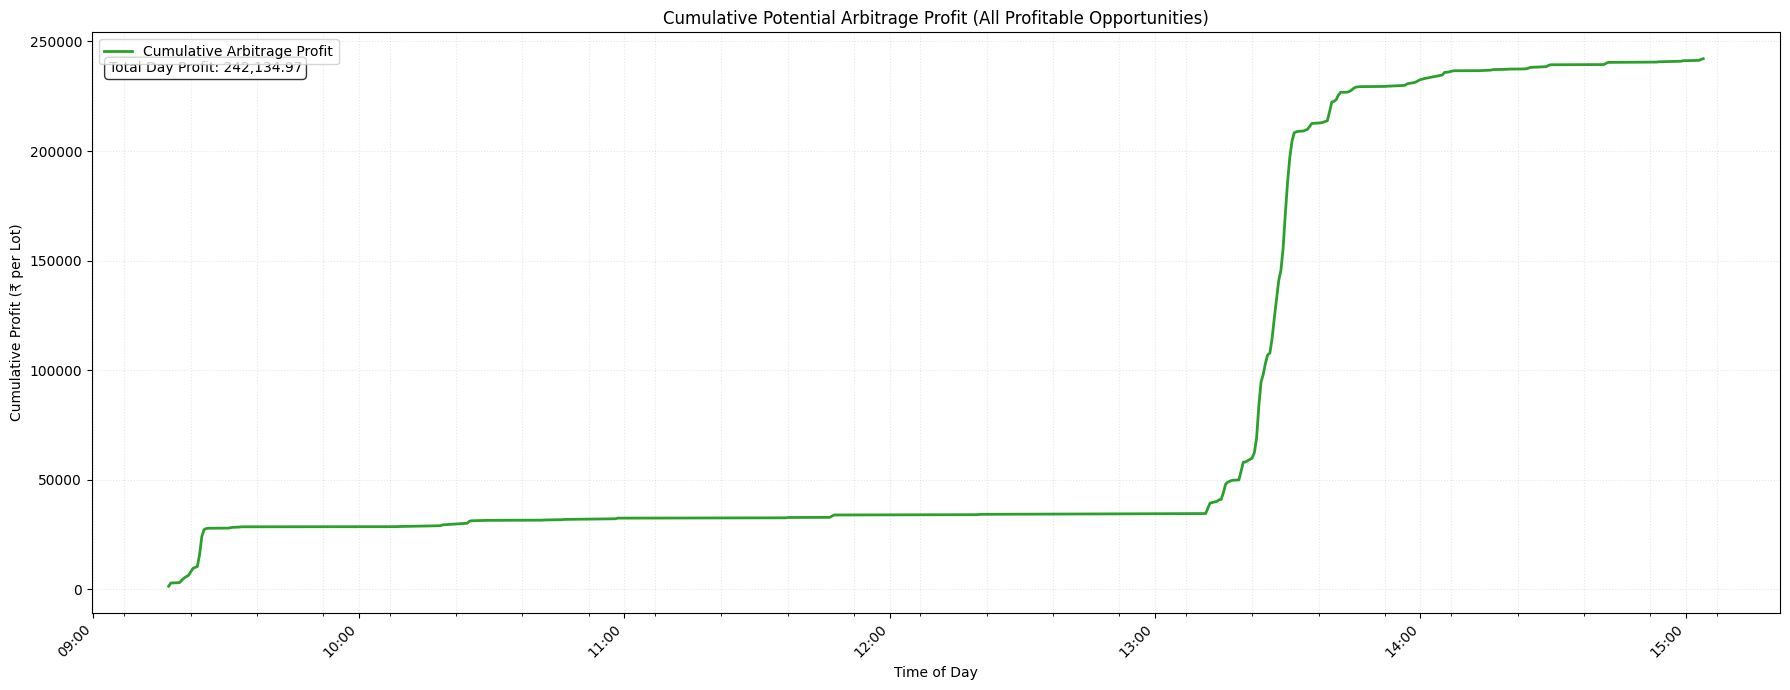

,fetch_time,interval_profit,opportunities_count,cumulative_profit
145,2026-04-06 14:59:00,245.443115,1,240982.701486
146,2026-04-06 14:59:30,245.619733,1,241228.321218
147,2026-04-06 15:03:00,134.848346,1,241363.169564
148,2026-04-06 15:03:30,453.322459,2,241816.492023
149,2026-04-06 15:04:00,318.473751,1,242134.965774


In [13]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df[(df['both_legs_liquid'] == True) & (df['both_legs_liquid_time_pct'] >= 100)],
    require_liquid=True,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()